In [1]:
import os
import glob
from datetime import timedelta
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

2026-07-22 11:23:30.091943: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
years = [2008, 2009, 2010, 2011, 2012]
original_hrdps_dir = ("/results/forcing/atmospheric/GEM2.5/gemlam")
time_fixed_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed")

fixed_2008_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    'gemlam_y2008m08d10.nc',
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
}

hrdps_files_by_year = {}
for year in years:
    original_files = glob.glob(os.path.join(original_hrdps_dir,f"gemlam_y{year}m??d??.nc"))
    files_by_name = {os.path.basename(file): file for file in original_files}
    if year == 2008:
        for filename in fixed_2008_filenames:
            fixed_file = os.path.join(time_fixed_dir,filename,)
            files_by_name[filename] = fixed_file

    files = [files_by_name[filename] for filename in sorted(files_by_name)]

    hrdps_files_by_year[year] = files

    print(year,":",files[0],"to",files[-1],f"({len(files)} files)")

2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)


In [3]:
# Loading datasets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [4]:
# Converts hourly HRDPS longwave_radiation from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time = pd.Timestamp("2011-09-22 00:00:00")

def interpolate_therm_rad_with_weights(therm_rad, ds_weights):
    therm_rad = therm_rad.transpose("time_counter", "y", "x")

    n_time = therm_rad.sizes["time_counter"]
    source_shape = (therm_rad.sizes["y"],therm_rad.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (therm_rad.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):
        # The source indexes in the weights file are 1-based
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index]* weight[None, :, :])

    therm_rad_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": therm_rad["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="therm_rad"
    )

    therm_rad_nemo.attrs = therm_rad.attrs.copy()
    therm_rad_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    therm_rad_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )
    return therm_rad_nemo

In [5]:
# Open file and interpolates

def extract_and_interpolate_hourly_therm_rad(file):
    with xr.open_dataset(file) as ds:
        therm_rad = ds["therm_rad"].sortby("time_counter")
        time_index = therm_rad.get_index("time_counter")

        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            therm_rad = therm_rad.isel(time_counter=unique_mask)

        therm_rad = therm_rad.load()

    times = pd.to_datetime(therm_rad["time_counter"].values)

    before_transition = times < transition_time
    after_transition = times >= transition_time

    pieces = []

    if before_transition.any():
        therm_rad_pre = therm_rad.isel(time_counter=np.where(before_transition)[0])
        interpolated_pre = interpolate_therm_rad_with_weights(therm_rad_pre,ds_weights_pre)
        pieces.append(interpolated_pre)

    if after_transition.any():
        therm_rad_post = therm_rad.isel(time_counter=np.where(after_transition)[0])
        interpolated_post = interpolate_therm_rad_with_weights(therm_rad_post,ds_weights_post)
        pieces.append(interpolated_post)

    therm_rad_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return therm_rad_nemo

In [6]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [7]:
def process_daily_file_to_3h_water(file):
    therm_rad_nemo_hourly = extract_and_interpolate_hourly_therm_rad(file)
    n_time = therm_rad_nemo_hourly.sizes["time_counter"]

    therm_rad_water_values = (therm_rad_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    therm_rad_water_hourly = xr.DataArray(therm_rad_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": therm_rad_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="therm_rad",attrs=therm_rad_nemo_hourly.attrs,)

    therm_rad_water_3h = therm_rad_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return therm_rad_water_3h.load()

In [8]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_therm_rad_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files,combine="by_coords")

ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["therm_rad"].shape)

<xarray.Dataset> Size: 5GB
Dimensions:       (time_counter: 14608, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    therm_rad     (time_counter, water_cell) float32 5GB dask.array<chunksize=(366, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS therm_rad interpolated onto NEMO surface w...
First time: 2008-01-01T00:00:00.000000000
Last time:  2012-12-31T21:00:00.000000000
Shape: (14608, 81383)


In [9]:
# Validation: 2008
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=slice("2008-01-01", "2008-12-31 23:59:59"))
# Training: 2009–2011
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=slice("2009-01-01", "2011-12-31 23:59:59"))
# Testing: 2012
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=slice("2012-01-01", "2012-12-31 23:59:59"))

In [10]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]

canrcm_variables = {"longwave": "rlds", "temperature": "tas", "humidity": "huss"}

canrcm_files = {}

for predictor_name, variable_name in canrcm_variables.items():
    selected_files = []
    for year in canrcm_years:
        pattern = f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_{variable_name}.nc"
        matches = sorted(glob.glob(pattern))
        if not matches:
            raise FileNotFoundError(f"No CanRCM {variable_name} file was found for {year}. Pattern used: {pattern}")
        selected_files.append(matches[0])
    canrcm_files[predictor_name] = selected_files
    print(f"\n{predictor_name}: using CanRCM variable {variable_name}")
    for file in selected_files:
        print(file)


longwave: using CanRCM variable rlds
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_rlds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_rlds.nc

temperature: using CanRCM variable tas
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_tas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_tas.nc

humidity: using CanRCM variable huss
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_huss.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_huss.nc
/results/forcing/CanRCM5/sc_nam22r55l

In [11]:
def open_and_shift_canrcm(files, variable_name):
    ds = xr.open_mfdataset(files, combine="by_coords")
    ds = ds[[variable_name]].sortby("time")
    shifted_time = np.array([time_value - timedelta(hours=3) for time_value in ds["time"].values])
    ds = ds.assign_coords(time=("time", shifted_time))
    return ds

opened_canrcm_datasets = {}

for predictor_name, variable_name in canrcm_variables.items():
    opened_canrcm_datasets[predictor_name] = open_and_shift_canrcm(files=canrcm_files[predictor_name], variable_name=variable_name)

aligned_predictor_datasets = xr.align(opened_canrcm_datasets["longwave"], opened_canrcm_datasets["temperature"], opened_canrcm_datasets["humidity"], join="inner")

ds_canrcm = xr.Dataset({"longwave": aligned_predictor_datasets[0]["rlds"], "temperature": aligned_predictor_datasets[1]["tas"], "humidity": aligned_predictor_datasets[2]["huss"]})

print(ds_canrcm)
print("First timestamp:", ds_canrcm["time"].values[0])
print("Last timestamp:", ds_canrcm["time"].values[-1])
print("Longwave shape:", ds_canrcm["longwave"].shape)
print("Temperature shape:", ds_canrcm["temperature"].shape)
print("Humidity shape:", ds_canrcm["humidity"].shape)
print("Longwave units:", ds_canrcm["longwave"].attrs.get("units", "units unavailable"))
print("Temperature units:", ds_canrcm["temperature"].attrs.get("units", "units unavailable"))
print("Humidity units:", ds_canrcm["humidity"].attrs.get("units", "units unavailable"))

/tmp/ipykernel_2088810/2536478175.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords")
/tmp/ipykernel_2088810/2536478175.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords")
/tmp/ipykernel_2088810/2536478175.py:2

<xarray.Dataset> Size: 20GB
Dimensions:      (rlon: 360, rlat: 320, time: 14600)
Coordinates:
  * rlon         (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon          (rlat, rlon) float64 922kB 231.7 231.9 232.0 ... 352.7 352.8
    lat          (rlat, rlon) float64 922kB 4.494 4.578 4.662 ... 58.63 58.47
  * rlat         (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * time         (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
Data variables:
    longwave     (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
    temperature  (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
    humidity     (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
First timestamp: 2008-01-01 00:00:00
Last timestamp: 2012-12-31 21:00:00
Longwave shape: (14600, 320, 360)
Temperature shape: (14600, 320, 360)
Humidity shape: (14600, 320, 360)
Longw

In [12]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values
nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180
lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))
lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))
print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [13]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]
lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = (lat_canrcm >= lat_min) & (lat_canrcm <= lat_max) & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max)
rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

if len(rlat_indices) == 0:
    raise ValueError("No CanRCM cells overlap the NEMO geographical region.")

rlat_min = int(rlat_indices.min())
rlat_max = int(rlat_indices.max())
rlon_min = int(rlon_indices.min())
rlon_max = int(rlon_indices.max())

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

predictor_names = ["longwave", "temperature", "humidity"]

ds_canrcm_cut = ds_canrcm[predictor_names].isel(rlat=slice(rlat_min, rlat_max + 1), rlon=slice(rlon_min, rlon_max + 1))

print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 60MB
Dimensions:      (time: 14600, rlat: 20, rlon: 17)
Coordinates:
  * time         (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat         (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon         (rlon) float64 136B -19.25 -19.03 -18.81 ... -15.95 -15.73
    lon          (rlat, rlon) float64 3kB 234.4 234.7 235.0 ... 237.0 237.3
    lat          (rlat, rlon) float64 3kB 46.47 46.54 46.62 ... 51.51 51.59
Data variables:
    longwave     (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
    temperature  (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
    humidity     (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>


In [14]:
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01", "2008-12-31 23:59:59"))
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01", "2011-12-31 23:59:59"))
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01", "2012-12-31 23:59:59"))
print("CanRCM validation:", ds_canrcm_val.sizes["time"])
print("CanRCM training:", ds_canrcm_train.sizes["time"])
print("CanRCM testing:", ds_canrcm_test.sizes["time"])

CanRCM validation: 2920
CanRCM training: 8760
CanRCM testing: 2920


In [15]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value, unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")
    raise TypeError(f"Unsupported time type: {type(value)}")

def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(time_value) for time_value in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(time_value) for time_value in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_indices, hrdps_indices = np.intersect1d(canrcm_times, hrdps_times, return_indices=True)
    if len(common_times) == 0:
        raise ValueError("No common CanRCM and HRDPS timestamps were found.")
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_indices)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_indices)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [16]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val, ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train, ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test, ds_hrdps_test)

print("Validation HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("Validation CanRCM:", ds_canrcm_val.sizes["time"])
print("Training HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("Training CanRCM:", ds_canrcm_train.sizes["time"])
print("Testing HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("Testing CanRCM:", ds_canrcm_test.sizes["time"])

assert ds_hrdps_val.sizes["time_counter"] == ds_canrcm_val.sizes["time"]
assert ds_hrdps_train.sizes["time_counter"] == ds_canrcm_train.sizes["time"]
assert ds_hrdps_test.sizes["time_counter"] == ds_canrcm_test.sizes["time"]

Validation HRDPS: 2920
Validation CanRCM: 2920
Training HRDPS: 8760
Training CanRCM: 8760
Testing HRDPS: 2912
Testing CanRCM: 2912


In [17]:
X_hrdps_train_raw = ds_hrdps_train["therm_rad"].values.astype(np.float32)
X_hrdps_val_raw = ds_hrdps_val["therm_rad"].values.astype(np.float32)
X_hrdps_test_raw = ds_hrdps_test["therm_rad"].values.astype(np.float32)
print("Raw HRDPS training shape:", X_hrdps_train_raw.shape)
print("Raw HRDPS validation shape:", X_hrdps_val_raw.shape)
print("Raw HRDPS testing shape:", X_hrdps_test_raw.shape)

Raw HRDPS training shape: (8760, 81383)
Raw HRDPS validation shape: (2920, 81383)
Raw HRDPS testing shape: (2912, 81383)


In [18]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95
X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()
hrdps_col_mean = np.nanmean(X_hrdps_train, axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError("At least one retained HRDPS cell has a non-finite training mean.")

def fill_with_training_mean(matrix, training_mean):
    matrix = matrix.copy()
    rows, columns = np.where(~np.isfinite(matrix))
    matrix[rows, columns] = training_mean[columns]
    return matrix

X_hrdps_train = fill_with_training_mean(X_hrdps_train, hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val, hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test, hrdps_col_mean)

print("Retained NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS training shape:", X_hrdps_train.shape)
print("Final HRDPS validation shape:", X_hrdps_val.shape)
print("Final HRDPS testing shape:", X_hrdps_test.shape)

Retained NEMO cells: 81383
Final HRDPS training shape: (8760, 81383)
Final HRDPS validation shape: (2920, 81383)
Final HRDPS testing shape: (2912, 81383)


In [19]:
valid_water_cell = ds_hrdps_train["water_cell"].values[valid_nemo_cols]
valid_nemo_j = ds_hrdps_train["nemo_j"].values[valid_nemo_cols]
valid_nemo_i = ds_hrdps_train["nemo_i"].values[valid_nemo_cols]
valid_nemo_lat = ds_hrdps_train["nav_lat"].values[valid_nemo_cols]
valid_nemo_lon = ds_hrdps_train["nav_lon"].values[valid_nemo_cols]
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [20]:
def make_canrcm_matrix(data_array):
    data_array = data_array.transpose("time", "rlat", "rlon")
    n_time = data_array.sizes["time"]
    matrix = data_array.values.reshape(n_time, -1).astype(np.float32)
    return matrix

canrcm_raw_matrices = {}

for predictor_name in predictor_names:
    canrcm_raw_matrices[predictor_name] = {}
    canrcm_raw_matrices[predictor_name]["train"] = make_canrcm_matrix(ds_canrcm_train[predictor_name])
    canrcm_raw_matrices[predictor_name]["validation"] = make_canrcm_matrix(ds_canrcm_val[predictor_name])
    canrcm_raw_matrices[predictor_name]["test"] = make_canrcm_matrix(ds_canrcm_test[predictor_name])
    print(f"\n{predictor_name}")
    print("Raw training shape:", canrcm_raw_matrices[predictor_name]["train"].shape)
    print("Raw validation shape:", canrcm_raw_matrices[predictor_name]["validation"].shape)
    print("Raw testing shape:", canrcm_raw_matrices[predictor_name]["test"].shape)


longwave
Raw training shape: (8760, 340)
Raw validation shape: (2920, 340)
Raw testing shape: (2912, 340)

temperature
Raw training shape: (8760, 340)
Raw validation shape: (2920, 340)
Raw testing shape: (2912, 340)

humidity
Raw training shape: (8760, 340)
Raw validation shape: (2920, 340)
Raw testing shape: (2912, 340)


In [21]:
def prepare_canrcm_predictor(raw_split_matrices):
    X_train_raw = raw_split_matrices["train"]
    X_val_raw = raw_split_matrices["validation"]
    X_test_raw = raw_split_matrices["test"]
    valid_fraction = np.isfinite(X_train_raw).mean(axis=0)
    valid_columns = valid_fraction > 0.95
    X_train = X_train_raw[:, valid_columns].copy()
    X_val = X_val_raw[:, valid_columns].copy()
    X_test = X_test_raw[:, valid_columns].copy()
    training_column_mean = np.nanmean(X_train, axis=0)
    if not np.all(np.isfinite(training_column_mean)):
        raise ValueError("At least one retained CanRCM cell has a non-finite training mean.")
    X_train = fill_with_training_mean(X_train, training_column_mean)
    X_val = fill_with_training_mean(X_val, training_column_mean)
    X_test = fill_with_training_mean(X_test, training_column_mean)
    return {"train": X_train, "validation": X_val, "test": X_test, "valid_columns": valid_columns, "training_column_mean": training_column_mean}

canrcm_matrices = {}

for predictor_name in predictor_names:
    canrcm_matrices[predictor_name] = prepare_canrcm_predictor(canrcm_raw_matrices[predictor_name])
    print(f"\n{predictor_name}")
    print("Retained grid cells:", canrcm_matrices[predictor_name]["valid_columns"].sum())
    print("Training shape:", canrcm_matrices[predictor_name]["train"].shape)
    print("Validation shape:", canrcm_matrices[predictor_name]["validation"].shape)
    print("Testing shape:", canrcm_matrices[predictor_name]["test"].shape)


longwave
Retained grid cells: 340
Training shape: (8760, 340)
Validation shape: (2920, 340)
Testing shape: (2912, 340)

temperature
Retained grid cells: 340
Training shape: (8760, 340)
Validation shape: (2920, 340)
Testing shape: (2912, 340)

humidity
Retained grid cells: 340
Training shape: (8760, 340)
Validation shape: (2920, 340)
Testing shape: (2912, 340)


In [22]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300, X_hrdps_train.shape[0] - 1, X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs, svd_solver="randomized", random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
print("HRDPS PCA components:", pca_hrdps.components_.shape)
print("HRDPS training scores:", hrdps_train_scores_all.shape)
print("Variance explained by all fitted PCs:", hrdps_cumulative_variance[-1])

HRDPS PCA components: (300, 81383)
HRDPS training scores: (8760, 300)
Variance explained by all fitted PCs: 0.9955478


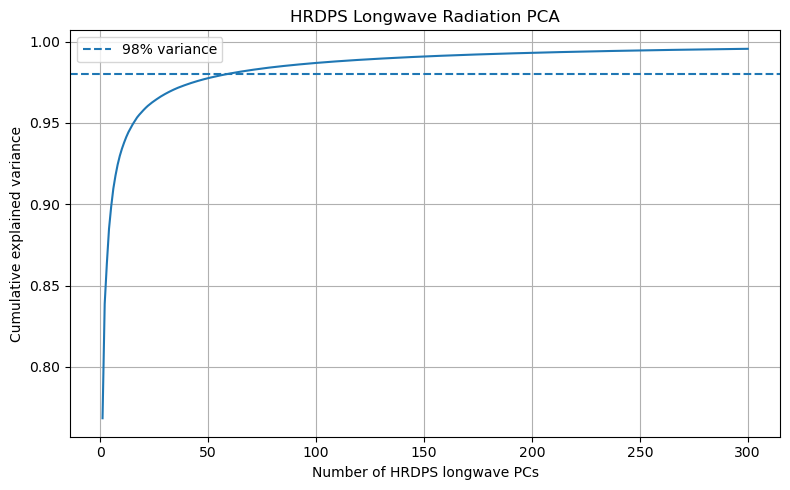

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1), hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold, linestyle="--", label="98% variance")
plt.xlabel("Number of HRDPS longwave PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS Longwave Radiation PCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]

if len(threshold_indices) == 0:
    raise ValueError("The requested HRDPS variance threshold was not reached.")

n_hrdps_pcs = int(threshold_indices[0] + 1)
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("Selected HRDPS longwave PCs:", n_hrdps_pcs)
print("Cumulative variance:", hrdps_cumulative_variance[n_hrdps_pcs - 1])
print("Training target scores:", hrdps_train_scores.shape)
print("Validation target scores:", hrdps_val_scores.shape)
print("Testing target scores:", hrdps_test_scores.shape)

Selected HRDPS longwave PCs: 59
Cumulative variance: 0.9801047
Training target scores: (8760, 59)
Validation target scores: (2920, 59)
Testing target scores: (2912, 59)


In [25]:
max_predictor_pcs_to_search = 100
predictor_pca_results = {}

for predictor_name in predictor_names:
    X_train_predictor = canrcm_matrices[predictor_name]["train"]
    X_val_predictor = canrcm_matrices[predictor_name]["validation"]
    X_test_predictor = canrcm_matrices[predictor_name]["test"]
    max_pcs = min(max_predictor_pcs_to_search, X_train_predictor.shape[0] - 1, X_train_predictor.shape[1])
    pca_predictor = PCA(n_components=max_pcs, svd_solver="randomized", random_state=0)
    train_scores_all = pca_predictor.fit_transform(X_train_predictor)
    val_scores_all = pca_predictor.transform(X_val_predictor)
    test_scores_all = pca_predictor.transform(X_test_predictor)
    predictor_pca_results[predictor_name] = {"pca": pca_predictor, "max_pcs": max_pcs, "train_scores_all": train_scores_all, "validation_scores_all": val_scores_all, "test_scores_all": test_scores_all, "cumulative_variance": np.cumsum(pca_predictor.explained_variance_ratio_)}
    print(f"\n{predictor_name}")
    print("PCA components:", pca_predictor.components_.shape)
    print("Training scores:", train_scores_all.shape)
    print("Validation scores:", val_scores_all.shape)
    print("Testing scores:", test_scores_all.shape)


longwave
PCA components: (100, 340)
Training scores: (8760, 100)
Validation scores: (2920, 100)
Testing scores: (2912, 100)

temperature
PCA components: (100, 340)
Training scores: (8760, 100)
Validation scores: (2920, 100)
Testing scores: (2912, 100)

humidity
PCA components: (100, 340)
Training scores: (8760, 100)
Validation scores: (2920, 100)
Testing scores: (2912, 100)


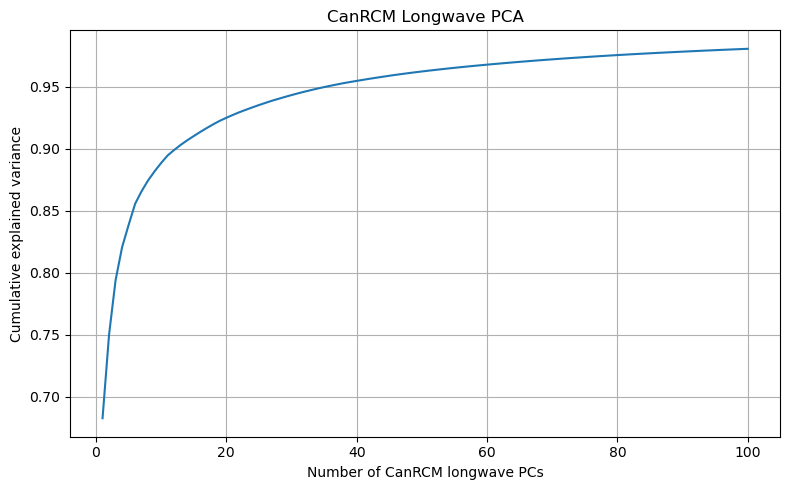

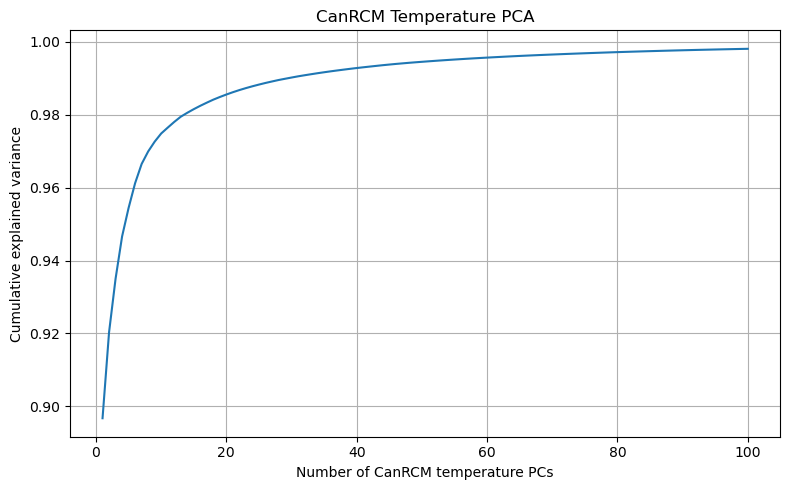

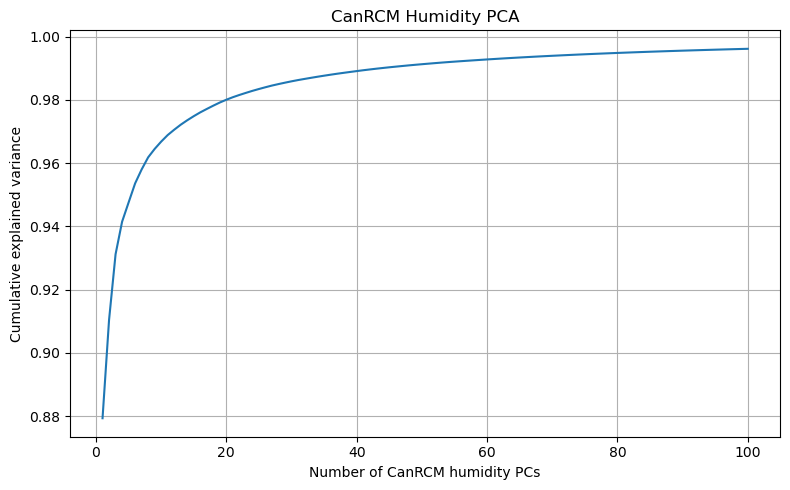

In [26]:
for predictor_name in predictor_names:
    cumulative_variance = predictor_pca_results[predictor_name]["cumulative_variance"]
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance)
    plt.xlabel(f"Number of CanRCM {predictor_name} PCs")
    plt.ylabel("Cumulative explained variance")
    plt.title(f"CanRCM {predictor_name.title()} PCA")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [27]:
def evaluate_candidate_pc_counts(candidate_train_scores, candidate_val_scores, target_train_scores, target_val_scores, fixed_train_parts=None, fixed_val_parts=None):
    if fixed_train_parts is None:
        fixed_train_parts = []
    if fixed_val_parts is None:
        fixed_val_parts = []
    candidates = np.arange(1, candidate_train_scores.shape[1] + 1)
    validation_r2_scores = []
    for n_candidate_pcs in candidates:
        train_parts = fixed_train_parts + [candidate_train_scores[:, :n_candidate_pcs]]
        val_parts = fixed_val_parts + [candidate_val_scores[:, :n_candidate_pcs]]
        X_train_candidate = np.concatenate(train_parts, axis=1)
        X_val_candidate = np.concatenate(val_parts, axis=1)
        candidate_model = LinearRegression()
        candidate_model.fit(X_train_candidate, target_train_scores)
        target_val_pred = candidate_model.predict(X_val_candidate)
        validation_r2 = r2_score(target_val_scores, target_val_pred, multioutput="variance_weighted")
        validation_r2_scores.append(validation_r2)
    validation_r2_scores = np.asarray(validation_r2_scores)
    best_index = int(np.nanargmax(validation_r2_scores))
    selected_pc_count = int(candidates[best_index])
    return {"candidates": candidates, "validation_r2_scores": validation_r2_scores, "selected_pc_count": selected_pc_count, "best_validation_r2": float(validation_r2_scores[best_index])}

In [28]:
predictor_pc_selection = {}
fixed_train_parts = []
fixed_val_parts = []

for predictor_name in predictor_names:
    train_scores_all = predictor_pca_results[predictor_name]["train_scores_all"]
    val_scores_all = predictor_pca_results[predictor_name]["validation_scores_all"]
    selection_result = evaluate_candidate_pc_counts(candidate_train_scores=train_scores_all, candidate_val_scores=val_scores_all, target_train_scores=hrdps_train_scores, target_val_scores=hrdps_val_scores, fixed_train_parts=fixed_train_parts, fixed_val_parts=fixed_val_parts)
    predictor_pc_selection[predictor_name] = selection_result
    n_selected = selection_result["selected_pc_count"]
    fixed_train_parts.append(train_scores_all[:, :n_selected])
    fixed_val_parts.append(val_scores_all[:, :n_selected])
    print(f"{predictor_name}: selected {n_selected} PCs")
    print("Best validation PC-space R²:", selection_result["best_validation_r2"])

selected_predictor_pc_counts = {predictor_name: predictor_pc_selection[predictor_name]["selected_pc_count"] for predictor_name in predictor_names}

print(selected_predictor_pc_counts)

longwave: selected 73 PCs
Best validation PC-space R²: 0.6189713478088379
temperature: selected 26 PCs
Best validation PC-space R²: 0.6397630572319031
humidity: selected 12 PCs
Best validation PC-space R²: 0.6457481980323792
{'longwave': 73, 'temperature': 26, 'humidity': 12}


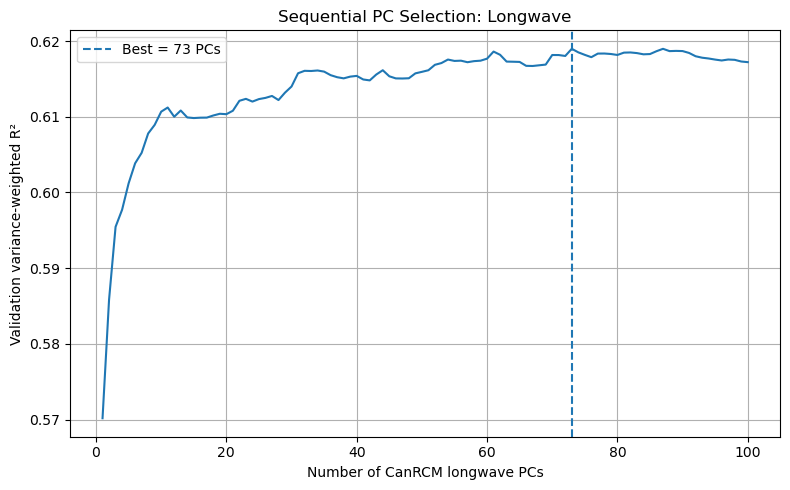

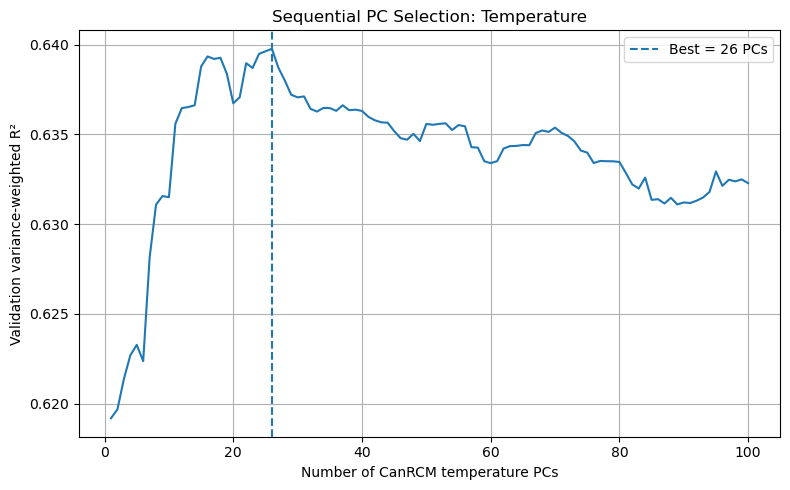

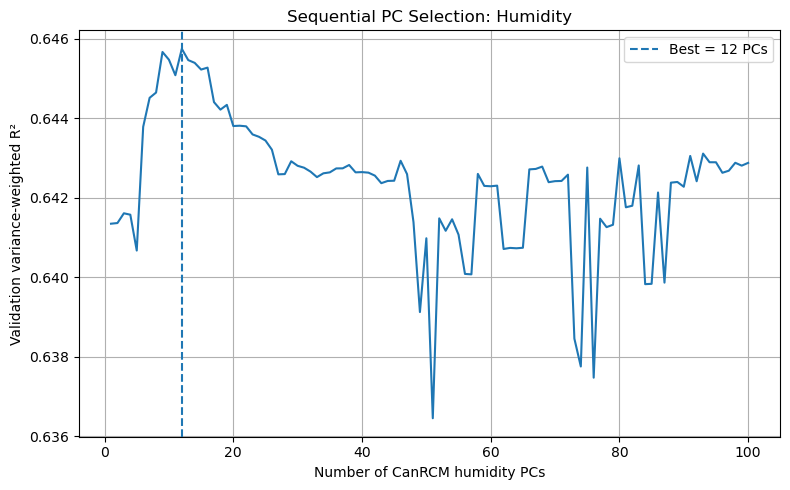

In [29]:
for predictor_name in predictor_names:
    selection_result = predictor_pc_selection[predictor_name]
    selected_pc_count = selection_result["selected_pc_count"]
    plt.figure(figsize=(8, 5))
    plt.plot(selection_result["candidates"], selection_result["validation_r2_scores"])
    plt.axvline(selected_pc_count, linestyle="--", label=f"Best = {selected_pc_count} PCs")
    plt.xlabel(f"Number of CanRCM {predictor_name} PCs")
    plt.ylabel("Validation variance-weighted R²")
    plt.title(f"Sequential PC Selection: {predictor_name.title()}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:
selected_train_pc_parts = []
selected_val_pc_parts = []
selected_test_pc_parts = []
pc_feature_slices = {}
feature_start = 0

for predictor_name in predictor_names:
    n_selected = selected_predictor_pc_counts[predictor_name]
    train_part = predictor_pca_results[predictor_name]["train_scores_all"][:, :n_selected]
    val_part = predictor_pca_results[predictor_name]["validation_scores_all"][:, :n_selected]
    test_part = predictor_pca_results[predictor_name]["test_scores_all"][:, :n_selected]
    selected_train_pc_parts.append(train_part)
    selected_val_pc_parts.append(val_part)
    selected_test_pc_parts.append(test_part)
    feature_end = feature_start + n_selected
    pc_feature_slices[predictor_name] = slice(feature_start, feature_end)
    feature_start = feature_end

X_train_pc_final = np.concatenate(selected_train_pc_parts, axis=1)
X_val_pc_final = np.concatenate(selected_val_pc_parts, axis=1)
X_test_pc_final = np.concatenate(selected_test_pc_parts, axis=1)

assert X_train_pc_final.shape[0] == hrdps_train_scores.shape[0]
assert X_val_pc_final.shape[0] == hrdps_val_scores.shape[0]
assert X_test_pc_final.shape[0] == hrdps_test_scores.shape[0]

print("Combined training predictors:", X_train_pc_final.shape)
print("Combined validation predictors:", X_val_pc_final.shape)
print("Combined testing predictors:", X_test_pc_final.shape)
print("Predictor feature slices:", pc_feature_slices)

Combined training predictors: (8760, 111)
Combined validation predictors: (2920, 111)
Combined testing predictors: (2912, 111)
Predictor feature slices: {'longwave': slice(0, 73, None), 'temperature': slice(73, 99, None), 'humidity': slice(99, 111, None)}


In [31]:
seed = 42
np.random.seed(seed)

tf.keras.utils.set_random_seed(seed)
predictor_pc_scaler = StandardScaler()
X_train_nn = predictor_pc_scaler.fit_transform(X_train_pc_final).astype(np.float32)
X_val_nn = predictor_pc_scaler.transform(X_val_pc_final).astype(np.float32)
X_test_nn = predictor_pc_scaler.transform(X_test_pc_final).astype(np.float32)
Y_train_nn = hrdps_train_scores.astype(np.float32)
Y_val_nn = hrdps_val_scores.astype(np.float32)
Y_test_nn = hrdps_test_scores.astype(np.float32)
print("Scaled training inputs:", X_train_nn.shape)
print("Scaled validation inputs:", X_val_nn.shape)
print("Scaled testing inputs:", X_test_nn.shape)
print("Unscaled training target PCs:", Y_train_nn.shape)
print("Unscaled validation target PCs:", Y_val_nn.shape)
print("Unscaled testing target PCs:", Y_test_nn.shape)
print("Training predictor mean:", np.mean(X_train_nn))
print("Training predictor standard deviation:", np.std(X_train_nn))
print("Target PC standard deviations:", np.std(Y_train_nn, axis=0))

Scaled training inputs: (8760, 111)
Scaled validation inputs: (2920, 111)
Scaled testing inputs: (2912, 111)
Unscaled training target PCs: (8760, 59)
Unscaled validation target PCs: (2920, 59)
Unscaled testing target PCs: (2912, 59)
Training predictor mean: 6.8262507e-10
Training predictor standard deviation: 1.0
Target PC standard deviations: [8534.956   2581.456   1534.2164  1422.4347  1134.5618  1027.1117
  872.91174  797.6074   716.2673   646.6542   598.0582   568.98083
  530.8939   486.54868  475.2912   447.61676  439.9028   394.43988
  373.3972   371.6568   357.65063  341.97446  321.369    312.80835
  302.94937  293.91586  289.10928  287.06213  275.04172  266.82166
  260.8896   254.89113  251.6556   241.26595  237.57156  231.2221
  222.23412  218.24242  213.98724  210.64638  206.96645  205.3921
  200.43158  197.6066   193.98175  191.32909  186.37712  184.58545
  181.48921  176.59326  175.15053  169.9051   168.8541   166.50562
  164.15425  163.8519   161.30301  159.59387  155.1064

In [32]:
def build_pc_fcnn(n_input_pcs, n_output_pcs):
    regularizer = tf.keras.regularizers.l2(1e-4)
    inputs = tf.keras.layers.Input(shape=(n_input_pcs,), name="multivariable_canrcm_pc_input")
    x = tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=regularizer, name="dense_1")(inputs)
    x = tf.keras.layers.Dropout(0.20, name="dropout_1")(x)
    x = tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=regularizer, name="dense_2")(x)
    x = tf.keras.layers.Dropout(0.20, name="dropout_2")(x)
    # x = tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=regularizer, name="dense_3")(x)
    outputs = tf.keras.layers.Dense(n_output_pcs, activation="linear", name="hrdps_longwave_pc_output")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="canrcm_longwave_temperature_humidity_to_hrdps_longwave_pc_fcnn")
    return model

In [33]:
n_input_pcs = int(X_train_pc_final.shape[1])
n_output_pcs = int(n_hrdps_pcs)

print("Longwave predictor PCs:", selected_predictor_pc_counts["longwave"])
print("Temperature predictor PCs:", selected_predictor_pc_counts["temperature"])
print("Humidity huss predictor PCs:", selected_predictor_pc_counts["humidity"])
print("Total FCNN predictor PCs:", n_input_pcs)
print("HRDPS longwave target PCs:", n_output_pcs)

tf.keras.backend.clear_session()

pc_fcnn = build_pc_fcnn(n_input_pcs=n_input_pcs, n_output_pcs=n_output_pcs)
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)
pc_fcnn.compile(optimizer=optimizer, loss="mse", metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
pc_fcnn.summary()

Longwave predictor PCs: 73
Temperature predictor PCs: 26
Humidity huss predictor PCs: 12
Total FCNN predictor PCs: 111
HRDPS longwave target PCs: 59


Model: "canrcm_longwave_temperature_humidity_to_hrdps_longwave_pc_fcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ multivariable_canrcm_pc_input   │ (None, 111)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hrdps_longwave_pc_output        │ (None, 59)             │         1,947 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,195 (43.73 KB)

 Trainable params: 11,195 (43.73 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
fcnn_output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_multivariable"
os.makedirs(fcnn_output_dir, exist_ok=True)
checkpoint_path = os.path.join(fcnn_output_dir, "best_longwave_temp_huss_unscaled_target_pc_fcnn.keras")
print("Checkpoint path:", checkpoint_path)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=18, min_delta=1e-4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

Checkpoint path: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_multivariable/best_longwave_temp_huss_unscaled_target_pc_fcnn.keras


In [35]:
history = pc_fcnn.fit(X_train_nn, Y_train_nn, validation_data=(X_val_nn, Y_val_nn), epochs=300, batch_size=64, shuffle=True, callbacks=callbacks, verbose=2)

Epoch 1/300

Epoch 1: val_loss improved from None to 1708478.62500, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_multivariable/best_longwave_temp_huss_unscaled_target_pc_fcnn.keras

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_multivariable/best_longwave_temp_huss_unscaled_target_pc_fcnn.keras
137/137 - 2s - 16ms/step - loss: 1574785.5000 - mae: 400.8146 - val_loss: 1708478.6250 - val_mae: 422.1350 - learning_rate: 3.0000e-04
Epoch 2/300

Epoch 2: val_loss improved from 1708478.62500 to 1707611.87500, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_multivariable/best_longwave_temp_huss_unscaled_target_pc_fcnn.keras

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/Neural_Networks/results_longwave_multivariable/best_longwave_temp_huss_unscaled_target_pc_fcnn.keras
137/137 - 0s - 3ms/step - 

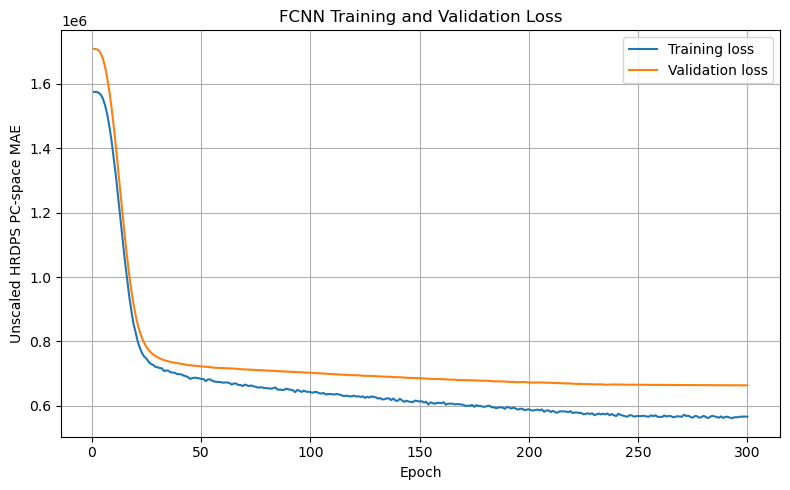

In [36]:
epochs_ran = range(1, len(history.history["loss"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Unscaled HRDPS PC-space MAE")
plt.title("FCNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

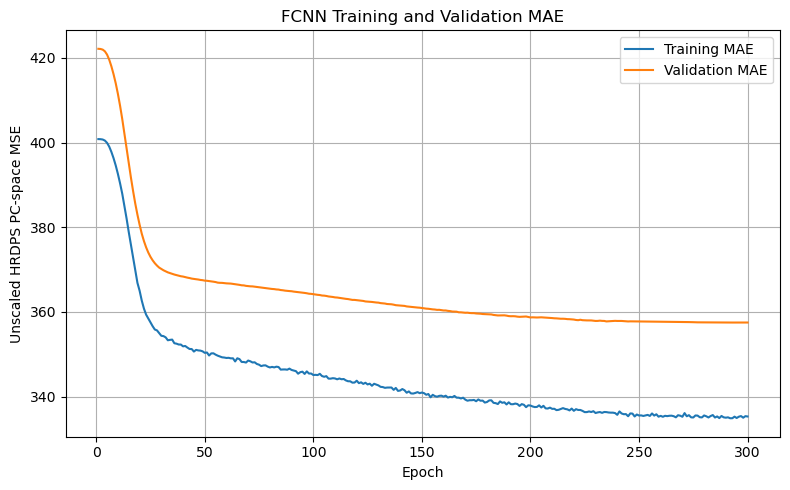

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["mae"], label="Training MAE")
plt.plot(epochs_ran, history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("Unscaled HRDPS PC-space MSE")
plt.title("FCNN Training and Validation MAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
best_pc_fcnn = tf.keras.models.load_model(checkpoint_path)
best_pc_fcnn.summary()

Model: "canrcm_longwave_temperature_humidity_to_hrdps_longwave_pc_fcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ multivariable_canrcm_pc_input   │ (None, 111)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hrdps_longwave_pc_output        │ (None, 59)             │         1,947 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,587 (131.20 KB)

 Trainable params: 11,195 (43.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,392 (87.47 KB)

In [39]:
def predict_hrdps_pc_scores(model, X_scaled):
    predicted_scores = model.predict(X_scaled, batch_size=256, verbose=1)
    return predicted_scores.astype(np.float32)

hrdps_val_scores_pred = predict_hrdps_pc_scores(best_pc_fcnn, X_val_nn)
hrdps_test_scores_pred = predict_hrdps_pc_scores(best_pc_fcnn, X_test_nn)
print("Predicted validation PC shape:", hrdps_val_scores_pred.shape)
print("Predicted testing PC shape:", hrdps_test_scores_pred.shape)
print("Actual validation PC standard deviations:", np.std(hrdps_val_scores, axis=0))
print("Predicted validation PC standard deviations:", np.std(hrdps_val_scores_pred, axis=0))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Predicted validation PC shape: (2920, 59)
Predicted testing PC shape: (2912, 59)
Actual validation PC standard deviations: [8895.464   2569.9011  1550.0579  1532.666   1159.8413  1123.6123
  950.0509   833.2622   766.58276  652.4373   607.50366  600.4607
  541.4673   511.4293   508.98367  458.3966   461.28806  403.91406
  411.1661   402.65717  373.19632  355.79086  346.23294  331.8033
  320.12823  315.41434  298.94385  294.12915  281.70853  286.25702
  244.93459  270.49994  269.4921   257.28912  240.77138  242.4154
  224.4985   227.62933  230.3107   216.43808  209.09598  211.72385
  211.18565  203.70592  207.72348  194.16031  195.36046  186.37613
  187.90468  181.27814  180.21303  175.86432  181.09953  176.243
  174.08519  170.64847  171.51535  163.94661  161.93338]
Predicted validation PC standard deviations: [7.1430537e+03 1.0122880e+03 1.5111516e+02 2.5094580e+02 7.3606125e+01
 9.5529411e+01 8.4686035e+0

In [40]:
def calculate_pc_metrics(true_scores, predicted_scores):
    error = predicted_scores - true_scores
    return {"pc_rmse": float(np.sqrt(np.mean(error**2, dtype=np.float64))), "pc_mae": float(np.mean(np.abs(error), dtype=np.float64)), "pc_bias": float(np.mean(error, dtype=np.float64)), "pc_r2_variance_weighted": float(r2_score(true_scores, predicted_scores, multioutput="variance_weighted"))}

val_pc_metrics = calculate_pc_metrics(hrdps_val_scores, hrdps_val_scores_pred)
test_pc_metrics = calculate_pc_metrics(hrdps_test_scores, hrdps_test_scores_pred)

pc_metrics_table = pd.DataFrame([{"split": "validation", **val_pc_metrics}, {"split": "test", **test_pc_metrics}])

pc_metrics_table

,split,pc_rmse,pc_mae,pc_bias,pc_r2_variance_weighted
0,validation,814.762594,357.485070,8.260402,0.610112
1,test,806.989126,348.101947,12.297030,0.534137


In [41]:
selected_hrdps_components = pca_hrdps.components_[:n_hrdps_pcs, :]

def reconstruct_from_hrdps_pcs(pc_scores):
    reconstructed = np.dot(pc_scores, selected_hrdps_components) + pca_hrdps.mean_
    return reconstructed.astype(np.float32)

X_hrdps_val_pred = reconstruct_from_hrdps_pcs(hrdps_val_scores_pred)
X_hrdps_test_pred = reconstruct_from_hrdps_pcs(hrdps_test_scores_pred)

print("Validation reconstructed shape:", X_hrdps_val_pred.shape)
print("Testing reconstructed shape:", X_hrdps_test_pred.shape)

Validation reconstructed shape: (2920, 81383)
Testing reconstructed shape: (2912, 81383)


In [42]:
def calculate_field_metrics(true_values, predicted_values):
    error = predicted_values - true_values
    rmse = float(np.sqrt(np.mean(error**2, dtype=np.float64)))
    true_standard_deviation = float(np.std(true_values, dtype=np.float64))
    normalized_rmse = rmse / true_standard_deviation if true_standard_deviation > 0 else np.nan
    true_domain_mean = np.mean(true_values, axis=1)
    predicted_domain_mean = np.mean(predicted_values, axis=1)
    return {"rmse": rmse, "normalized_rmse": float(normalized_rmse), "mae": float(np.mean(np.abs(error), dtype=np.float64)), "bias": float(np.mean(error, dtype=np.float64)), "grid_cell_r2": float(r2_score(true_values, predicted_values, multioutput="variance_weighted")), "domain_mean_r2": float(r2_score(true_domain_mean, predicted_domain_mean)), "number_valid_values": int(true_values.size)}

val_field_metrics = calculate_field_metrics(X_hrdps_val, X_hrdps_val_pred)
test_field_metrics = calculate_field_metrics(X_hrdps_test, X_hrdps_test_pred)
therm_rad_units = ds_hrdps_train["therm_rad"].attrs.get("units", "HRDPS therm_rad units")

field_metrics_table = pd.DataFrame([{"split": "validation", "units": therm_rad_units, **val_field_metrics}, {"split": "test", "units": therm_rad_units, **test_field_metrics}])

field_metrics_table

,split,units,rmse,normalized_rmse,mae,bias,grid_cell_r2,domain_mean_r2,number_valid_values
0,validation,W/m^2,22.520762,0.630590,17.555586,0.937382,0.597551,0.751426,237638360
1,test,W/m^2,22.389220,0.689441,17.168724,3.758731,0.519006,0.689407,236987296


In [43]:
X_hrdps_val_pca_only = reconstruct_from_hrdps_pcs(hrdps_val_scores)
X_hrdps_test_pca_only = reconstruct_from_hrdps_pcs(hrdps_test_scores)

pca_only_metrics_table = pd.DataFrame([
    {"split": "validation", **calculate_field_metrics(X_hrdps_val, X_hrdps_val_pca_only)},
    {"split": "test", **calculate_field_metrics(X_hrdps_test, X_hrdps_test_pca_only)}
])

pca_only_metrics_table

,split,rmse,normalized_rmse,mae,bias,grid_cell_r2,domain_mean_r2,number_valid_values
0,validation,5.091574,0.142566,3.111521,-0.000069,0.979429,1.0,237638360
1,test,5.399648,0.166274,3.264580,-0.000188,0.972023,1.0,236987296


In [44]:
def values_to_datetime_index(time_values):
    return pd.DatetimeIndex([pd.Timestamp(time_to_string(value)) for value in time_values])

val_times = values_to_datetime_index(ds_hrdps_val["time_counter"].values)
test_times = values_to_datetime_index(ds_hrdps_test["time_counter"].values)

print(val_times[0], val_times[-1], len(val_times))
print(test_times[0], test_times[-1], len(test_times))

2008-01-01 00:00:00 2008-12-31 21:00:00 2920
2012-01-01 00:00:00 2012-12-31 21:00:00 2912


In [45]:
def plot_domain_mean_timeseries(times, true_values, predicted_values, split_name, frequency=None):
    true_mean = np.mean(true_values, axis=1)
    predicted_mean = np.mean(predicted_values, axis=1)
    time_series = pd.DataFrame({"Actual": true_mean, "Predicted": predicted_mean}, index=times)
    if frequency is not None:
        time_series = time_series.resample(frequency).mean()
    frequency_label = "Daily Mean" if frequency == "D" else "3-Hourly"
    plt.figure(figsize=(14, 5))
    plt.plot(time_series.index, time_series["Actual"], label="Actual HRDPS", linewidth=1.5)
    plt.plot(time_series.index, time_series["Predicted"], label="Predicted FCNN", linewidth=1.5)
    plt.xlabel("Date")
    plt.ylabel(f"Spatial mean longwave radiation ({therm_rad_units})")
    plt.title(f"{split_name}: {frequency_label} Spatial Mean Longwave Radiation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return time_series

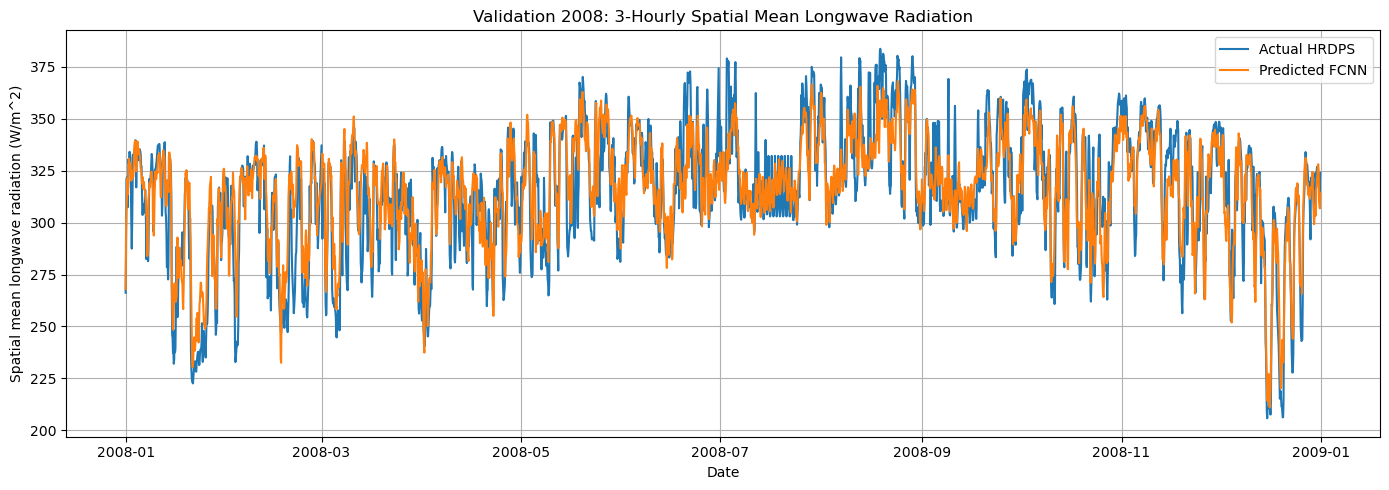

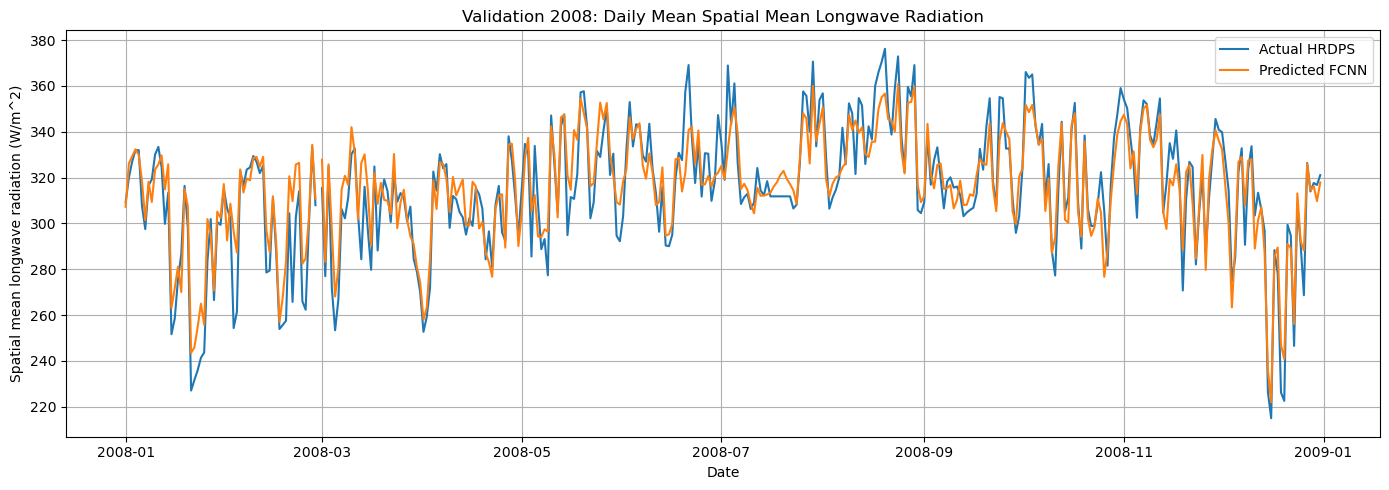

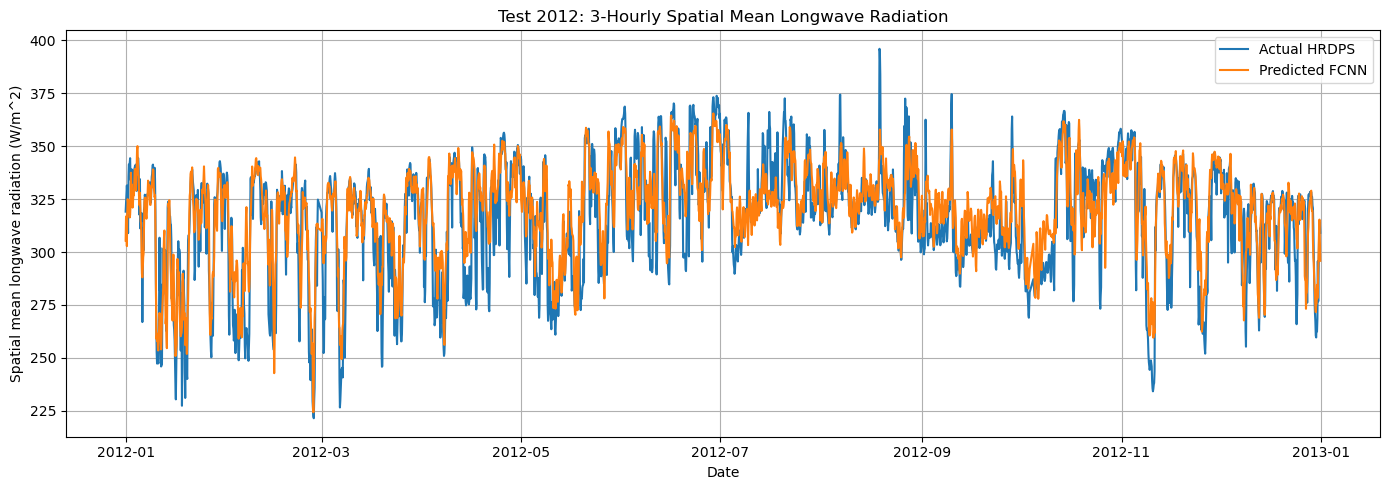

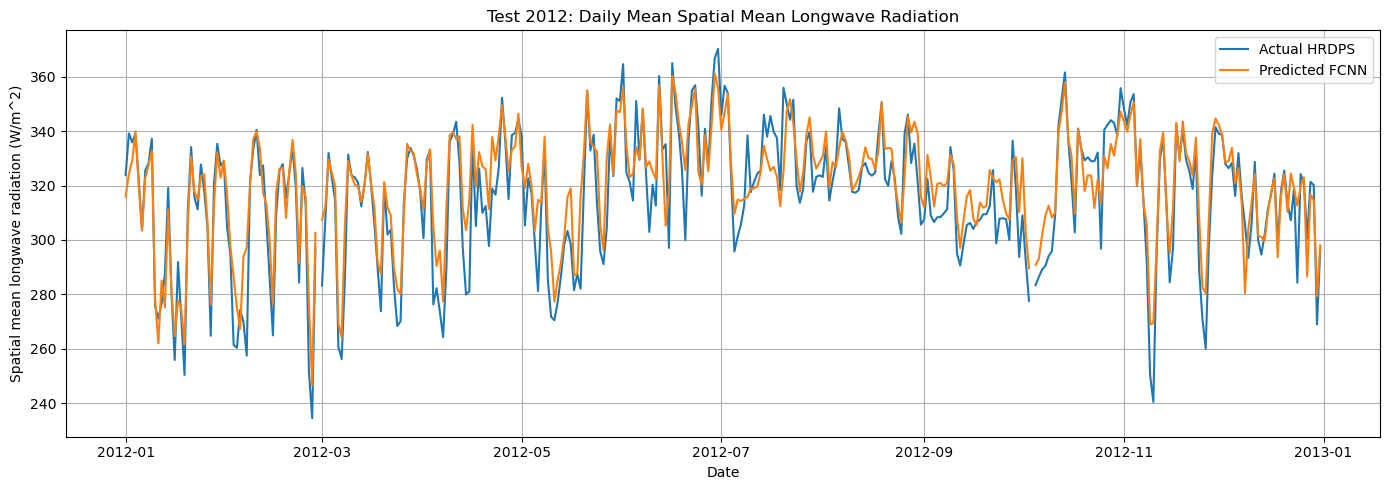

In [46]:
val_domain_3h = plot_domain_mean_timeseries(val_times, X_hrdps_val, X_hrdps_val_pred, "Validation 2008", frequency=None)
val_domain_daily = plot_domain_mean_timeseries(val_times, X_hrdps_val, X_hrdps_val_pred, "Validation 2008", frequency="D")
test_domain_3h = plot_domain_mean_timeseries(test_times, X_hrdps_test, X_hrdps_test_pred, "Test 2012", frequency=None)
test_domain_daily = plot_domain_mean_timeseries(test_times, X_hrdps_test, X_hrdps_test_pred, "Test 2012", frequency="D")

In [47]:
stations = {"Sand Heads": {"j": 426, "i": 293}, "Halibut Bank": {"j": 503, "i": 261}, "Sentry Shoal": {"j": 707, "i": 145}}

def find_station_column(station_j, station_i):
    exact_match = np.where((valid_nemo_j == station_j) & (valid_nemo_i == station_i))[0]
    if len(exact_match) == 1:
        return int(exact_match[0])
    if len(exact_match) > 1:
        raise ValueError("More than one retained column matches the station.")
    squared_distance = (valid_nemo_j - station_j) ** 2 + (valid_nemo_i - station_i) ** 2
    nearest_column = int(np.argmin(squared_distance))
    print("Exact retained cell not found for:", (station_j, station_i))
    print("Using nearest retained cell:", (int(valid_nemo_j[nearest_column]), int(valid_nemo_i[nearest_column])))
    return nearest_column

station_columns = {}

for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"], station_info["i"])
    station_columns[station_name] = column
    print(station_name, "column:", column, "NEMO cell:", (int(valid_nemo_j[column]), int(valid_nemo_i[column])), "latitude:", float(valid_nemo_lat[column]), "longitude:", float(valid_nemo_lon[column]))

Sand Heads column: 44165 NEMO cell: (426, 293) latitude: 49.099735260009766 longitude: -123.29531860351562
Halibut Bank column: 53329 NEMO cell: (503, 261) latitude: 49.3411979675293 longitude: -123.71952056884766
Sentry Shoal column: 71870 NEMO cell: (707, 145) latitude: 49.92068862915039 longitude: -125.00068664550781


In [48]:
def calculate_series_metrics(true_series, predicted_series):
    error = predicted_series - true_series
    rmse = float(np.sqrt(np.mean(error**2, dtype=np.float64)))
    true_standard_deviation = float(np.std(true_series, dtype=np.float64))
    normalized_rmse = rmse / true_standard_deviation if true_standard_deviation > 0 else np.nan
    return {"rmse": rmse, "normalized_rmse": float(normalized_rmse), "mae": float(np.mean(np.abs(error), dtype=np.float64)), "bias": float(np.mean(error, dtype=np.float64)), "r2": float(r2_score(true_series, predicted_series)), "number_values": int(len(true_series))}

station_metric_rows = []
split_data = {"validation": {"true": X_hrdps_val, "predicted": X_hrdps_val_pred}, "test": {"true": X_hrdps_test, "predicted": X_hrdps_test_pred}}

for split_name, values in split_data.items():
    for station_name, column in station_columns.items():
        true_station = values["true"][:, column]
        predicted_station = values["predicted"][:, column]
        station_metrics = calculate_series_metrics(true_station, predicted_station)
        station_metric_rows.append({"split": split_name, "station": station_name, "nemo_j": int(valid_nemo_j[column]), "nemo_i": int(valid_nemo_i[column]), "latitude": float(valid_nemo_lat[column]), "longitude": float(valid_nemo_lon[column]), "units": therm_rad_units, **station_metrics})

station_metrics_table = pd.DataFrame(station_metric_rows)

station_metrics_table

,split,station,nemo_j,nemo_i,latitude,longitude,units,rmse,normalized_rmse,mae,bias,r2,number_values
0,validation,Sand Heads,426,293,49.099735,-123.295319,W/m^2,21.936977,0.599189,16.841205,1.164391,0.640972,2920
1,validation,Halibut Bank,503,261,49.341198,-123.719521,W/m^2,21.919758,0.604673,16.891213,1.531287,0.634371,2920
2,validation,Sentry Shoal,707,145,49.920689,-125.000687,W/m^2,22.336173,0.606517,17.701964,1.371065,0.632137,2920
3,test,Sand Heads,426,293,49.099735,-123.295319,W/m^2,21.796631,0.677796,16.232512,3.857177,0.540593,2912
4,test,Halibut Bank,503,261,49.341198,-123.719521,W/m^2,21.509030,0.668039,16.043920,4.359053,0.553724,2912
5,test,Sentry Shoal,707,145,49.920689,-125.000687,W/m^2,21.993505,0.666496,16.959026,4.180699,0.555782,2912


In [49]:
average_station_rmse = station_metrics_table.groupby("split")["rmse"].mean().reset_index(name="average_station_rmse")

average_station_rmse

,split,average_station_rmse
0,test,21.766389
1,validation,22.064303


In [50]:
def plot_station_timeseries(times, true_values, predicted_values, station_name, station_column, split_name, frequency="D"):
    station_series = pd.DataFrame({"Actual": true_values[:, station_column], "Predicted": predicted_values[:, station_column]}, index=times)
    if frequency is not None:
        station_series = station_series.resample(frequency).mean()
    frequency_label = "Daily Mean" if frequency == "D" else "3-Hourly"
    plt.figure(figsize=(14, 5))
    plt.plot(station_series.index, station_series["Actual"], label="Actual HRDPS", linewidth=1.5)
    plt.plot(station_series.index, station_series["Predicted"], label="Predicted FCNN", linewidth=1.5)
    plt.xlabel("Date")
    plt.ylabel(f"Longwave radiation ({therm_rad_units})")
    plt.title(f"{split_name}: {station_name} {frequency_label} Longwave Radiation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return station_series

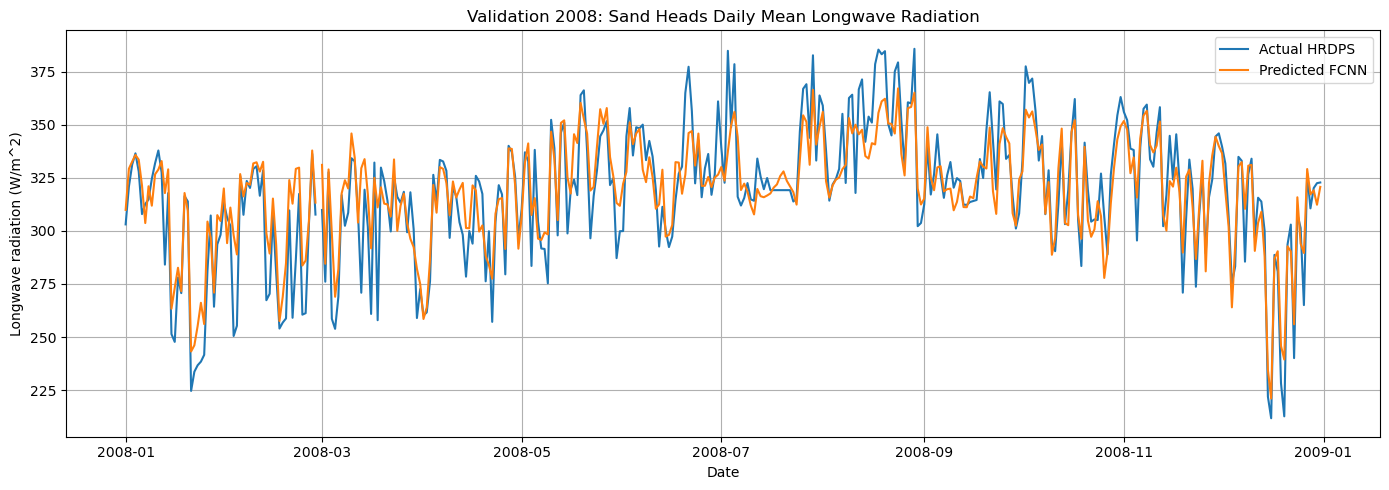

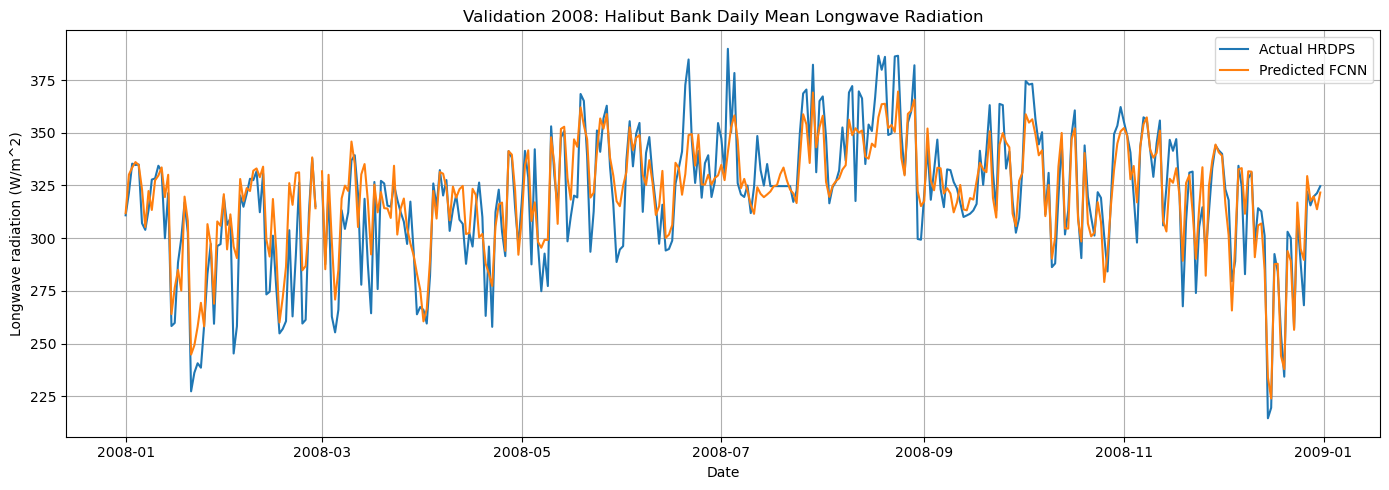

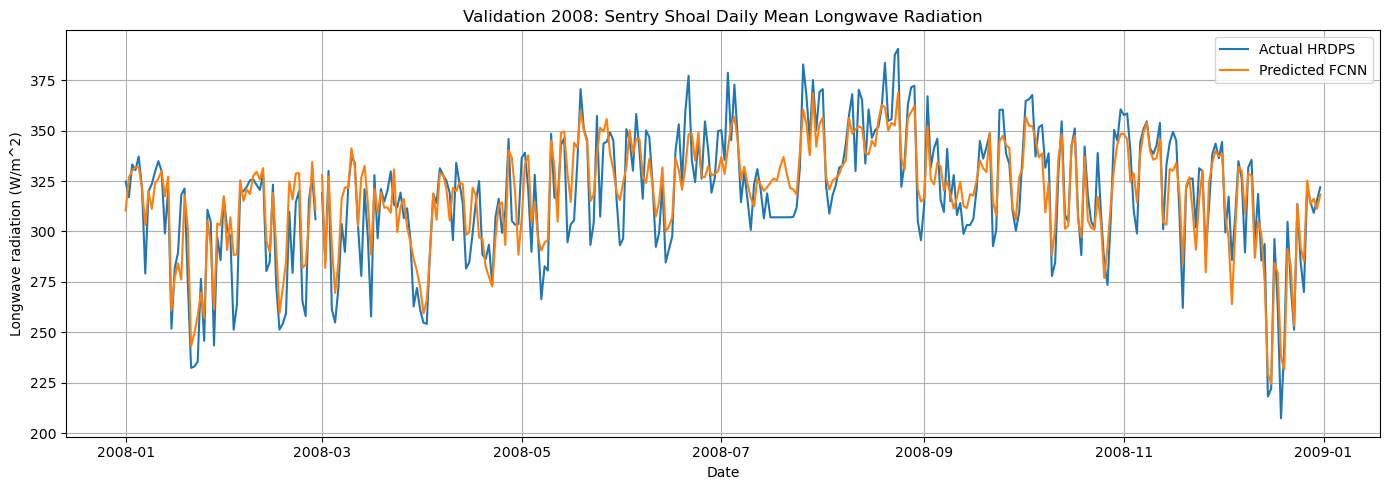

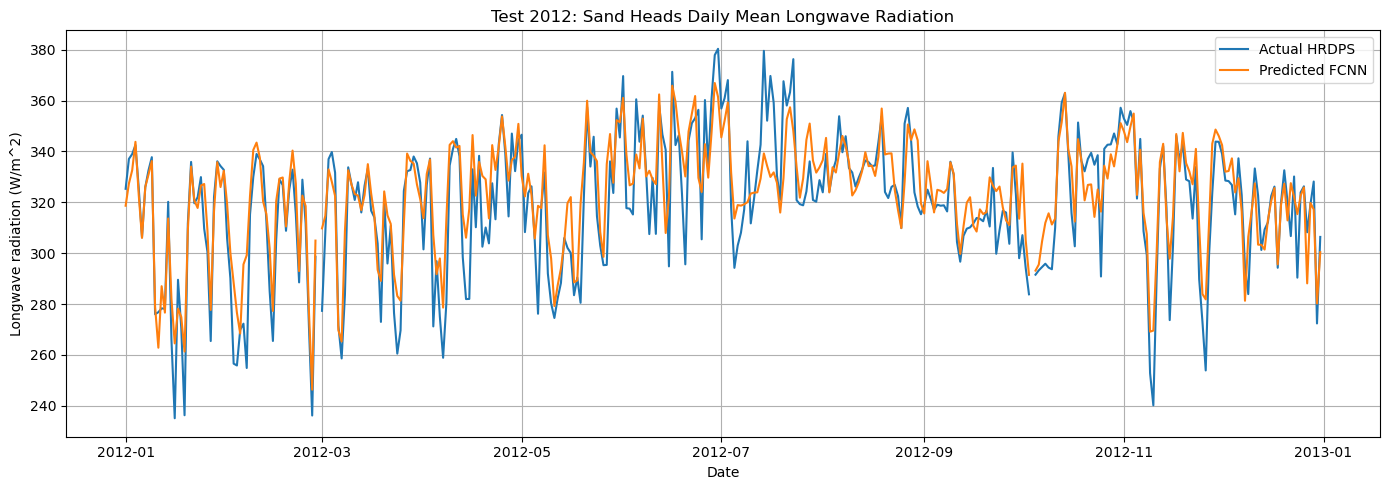

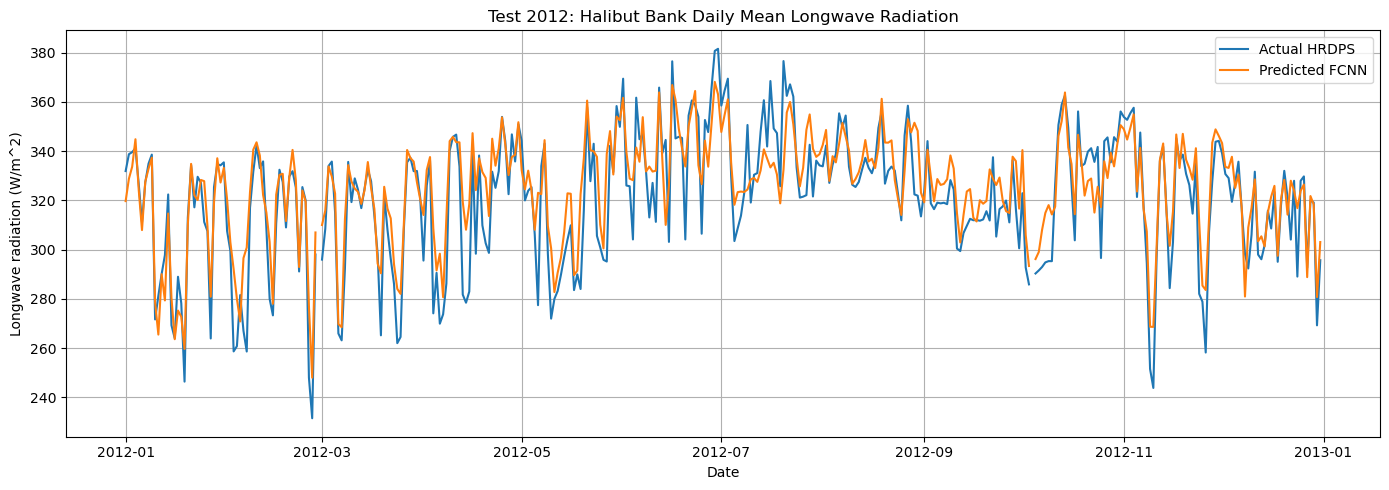

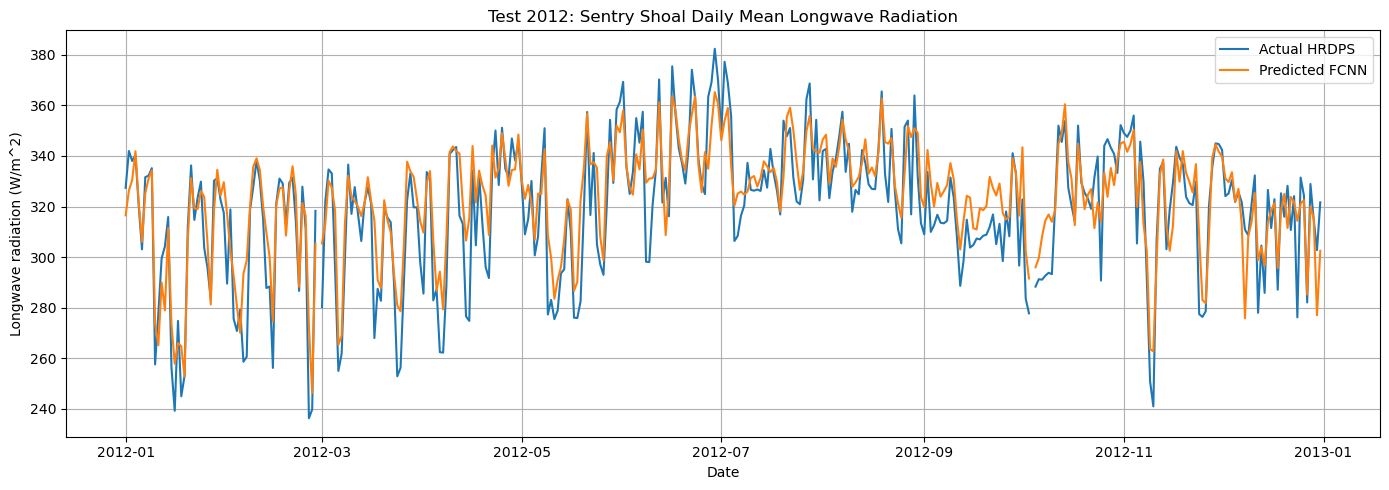

In [51]:
validation_station_series = {}

for station_name, column in station_columns.items():
    validation_station_series[station_name] = plot_station_timeseries(val_times, X_hrdps_val, X_hrdps_val_pred, station_name, column, "Validation 2008", frequency="D")

test_station_series = {}

for station_name, column in station_columns.items():
    test_station_series[station_name] = plot_station_timeseries(test_times, X_hrdps_test, X_hrdps_test_pred, station_name, column, "Test 2012", frequency="D")

In [52]:
def vector_to_nemo_map(vector):
    nemo_map = np.full(water_mask.shape, np.nan, dtype=np.float32)
    nemo_map[valid_nemo_j.astype(int), valid_nemo_i.astype(int)] = vector
    return nemo_map

example_map = vector_to_nemo_map(X_hrdps_test[0])

print("Map shape:", example_map.shape)
print("Number of finite cells:", np.isfinite(example_map).sum())

Map shape: (898, 398)
Number of finite cells: 81383


In [53]:
def plot_spatial_pattern(times, true_values, predicted_values, requested_timestamp, split_name):
    requested_timestamp = pd.Timestamp(requested_timestamp)
    time_index = times.get_indexer([requested_timestamp], method="nearest")[0]
    selected_timestamp = times[time_index]
    true_map = vector_to_nemo_map(true_values[time_index])
    predicted_map = vector_to_nemo_map(predicted_values[time_index])
    error_map = predicted_map - true_map
    true_and_predicted = np.concatenate([true_map[np.isfinite(true_map)], predicted_map[np.isfinite(predicted_map)]])
    radiation_vmin = np.nanpercentile(true_and_predicted, 2)
    radiation_vmax = np.nanpercentile(true_and_predicted, 98)
    error_limit = np.nanpercentile(np.abs(error_map), 98)
    if not np.isfinite(error_limit) or error_limit == 0:
        error_limit = 1e-6
    figure, axes = plt.subplots(1, 3, figsize=(19, 6), constrained_layout=True)
    actual_mesh = axes[0].pcolormesh(nemo_lon_2d, nemo_lat_2d, true_map, shading="auto", cmap="viridis", vmin=radiation_vmin, vmax=radiation_vmax)
    axes[0].set_title("Actual HRDPS")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    axes[1].pcolormesh(nemo_lon_2d, nemo_lat_2d, predicted_map, shading="auto", cmap="viridis", vmin=radiation_vmin, vmax=radiation_vmax)
    axes[1].set_title("Predicted FCNN")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    error_mesh = axes[2].pcolormesh(nemo_lon_2d, nemo_lat_2d, error_map, shading="auto", cmap="RdBu_r", vmin=-error_limit, vmax=error_limit)
    axes[2].set_title("Prediction − Actual")
    axes[2].set_xlabel("Longitude")
    axes[2].set_ylabel("Latitude")
    figure.colorbar(actual_mesh, ax=axes[:2], label=f"Longwave radiation ({therm_rad_units})", shrink=0.85)
    figure.colorbar(error_mesh, ax=axes[2], label=f"Longwave radiation error ({therm_rad_units})", shrink=0.85)
    figure.suptitle(f"{split_name}: {selected_timestamp}")
    plt.show()
    print("Requested timestamp:", requested_timestamp)
    print("Selected timestamp:", selected_timestamp)

/tmp/ipykernel_2088810/1847287400.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  actual_mesh = axes[0].pcolormesh(nemo_lon_2d, nemo_lat_2d, true_map, shading="auto", cmap="viridis", vmin=radiation_vmin, vmax=radiation_vmax)
/tmp/ipykernel_2088810/1847287400.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axes[1].pcolormesh(nemo_lon_2d, nemo_lat_2d, predicted_map, shading="auto", cmap="viridis", vmin=radiation_vmin, vmax=radiation_vmax)
/tmp/ipykernel_2088810/1847287400.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not mo

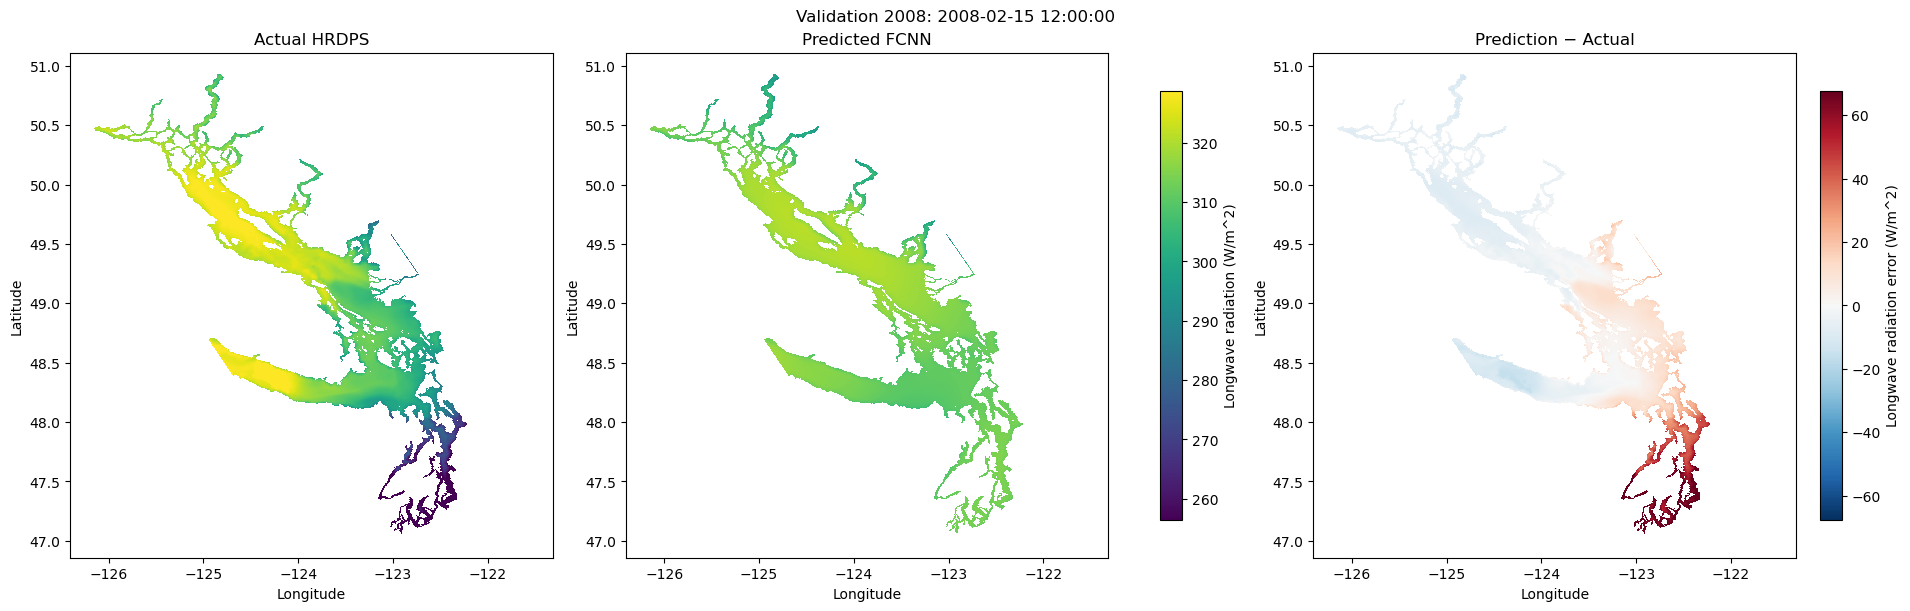

Requested timestamp: 2008-02-15 12:00:00
Selected timestamp: 2008-02-15 12:00:00


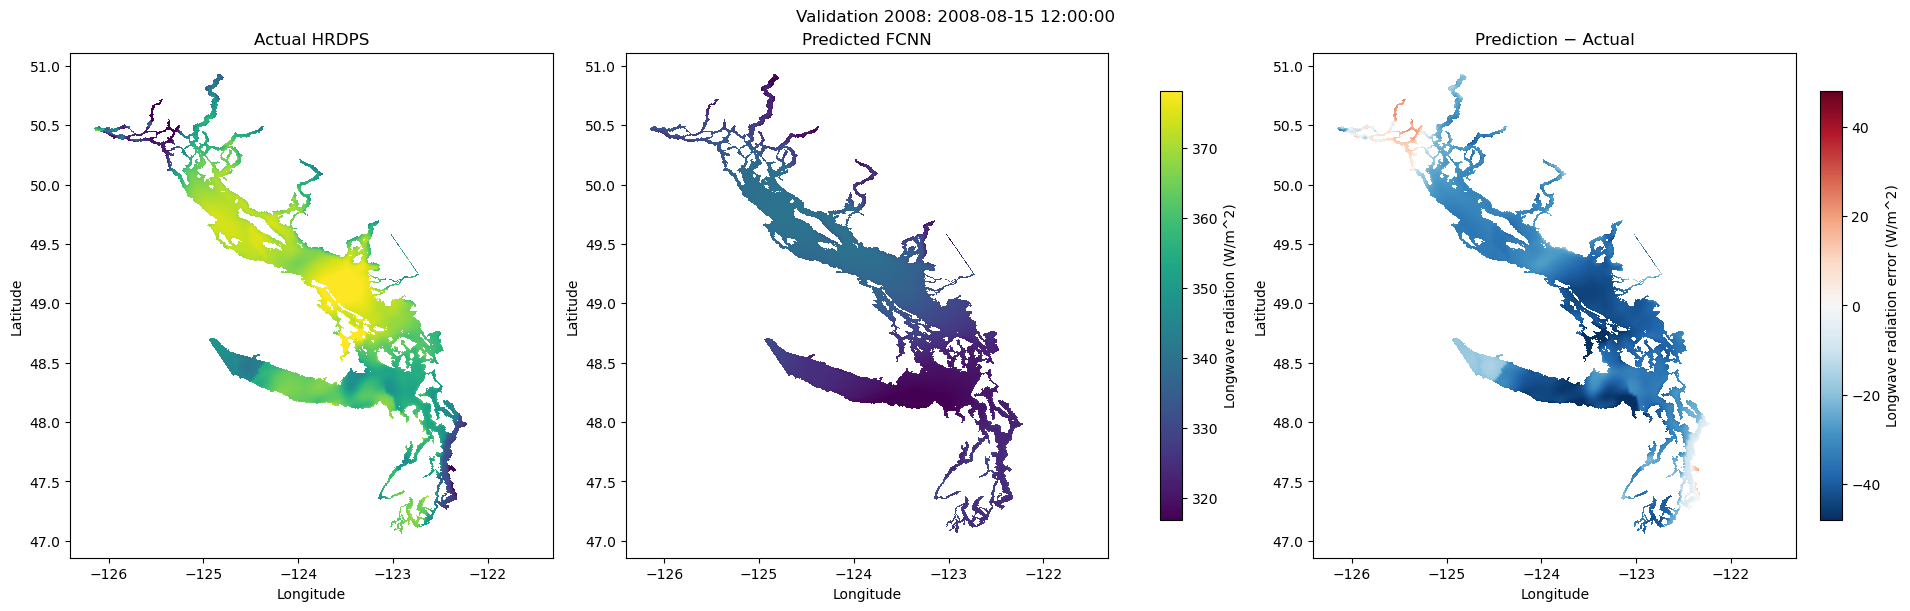

Requested timestamp: 2008-08-15 12:00:00
Selected timestamp: 2008-08-15 12:00:00


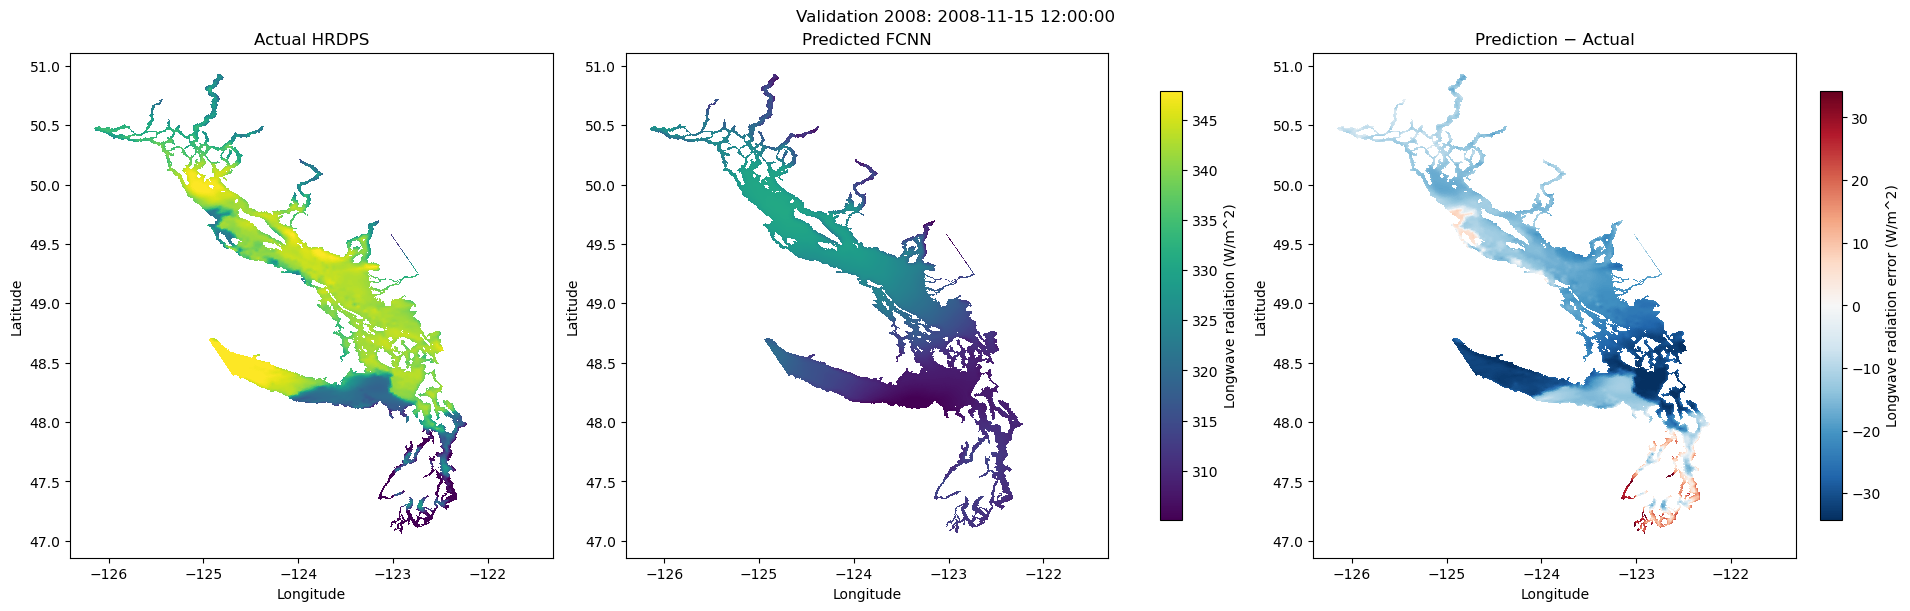

Requested timestamp: 2008-11-15 12:00:00
Selected timestamp: 2008-11-15 12:00:00


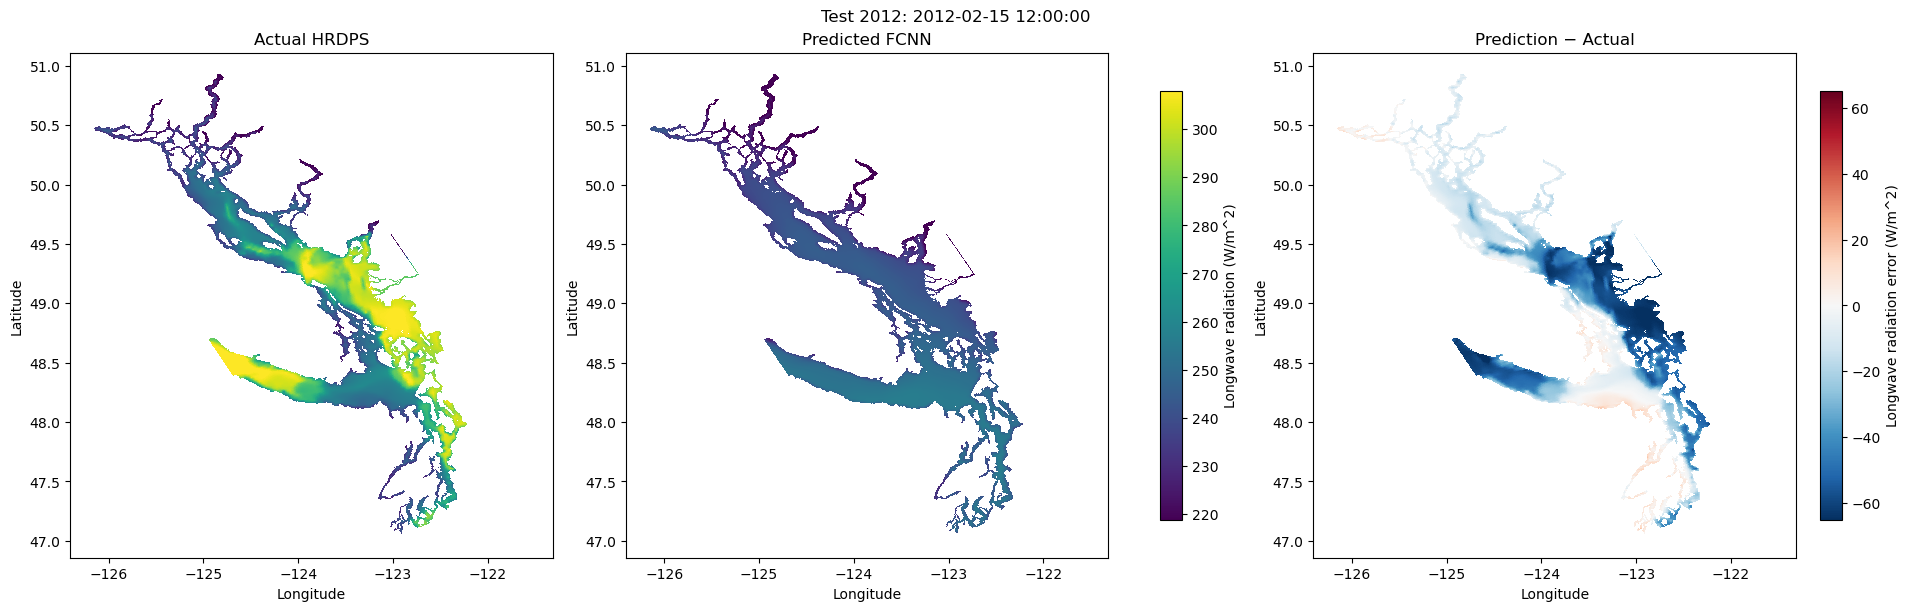

Requested timestamp: 2012-02-15 12:00:00
Selected timestamp: 2012-02-15 12:00:00


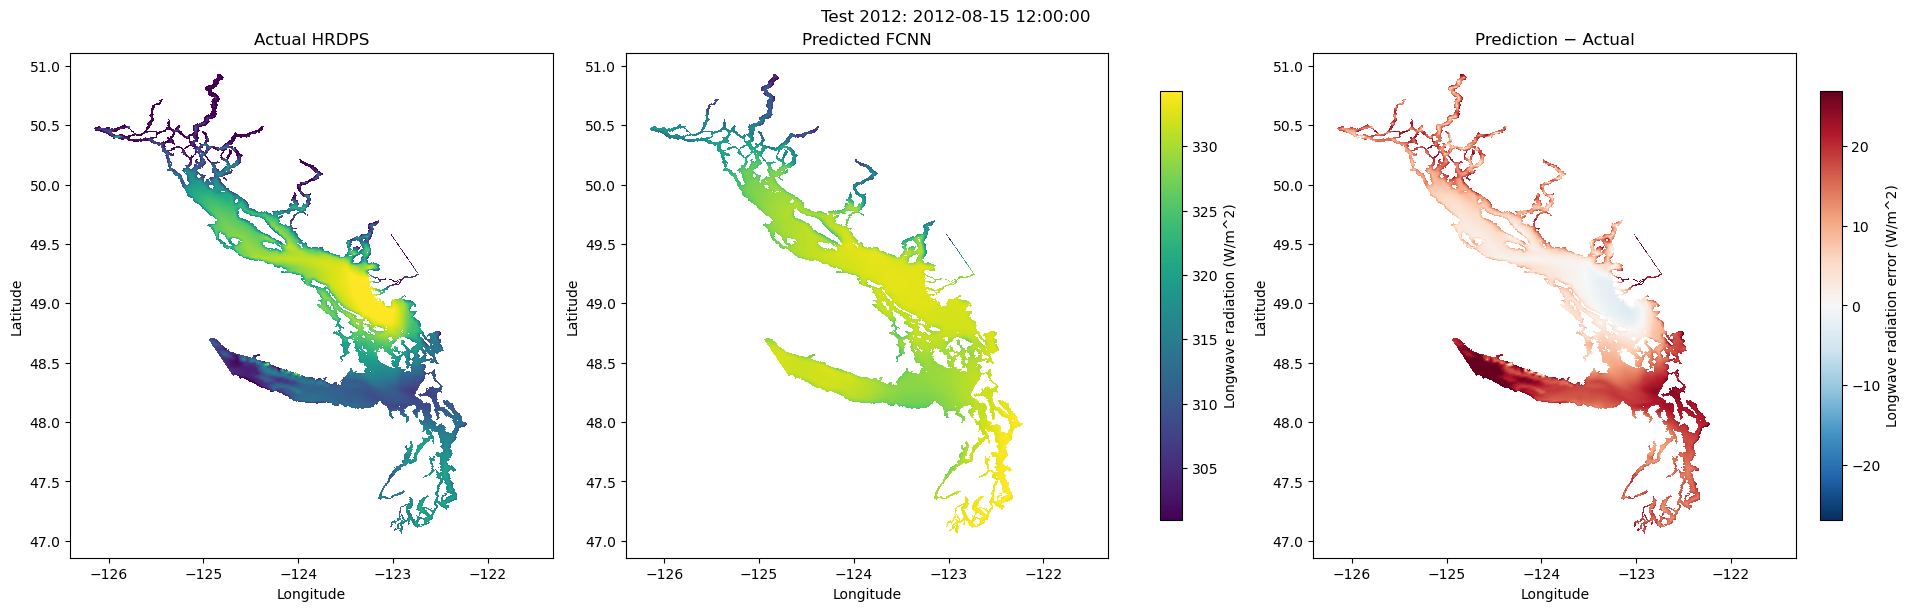

Requested timestamp: 2012-08-15 12:00:00
Selected timestamp: 2012-08-15 12:00:00


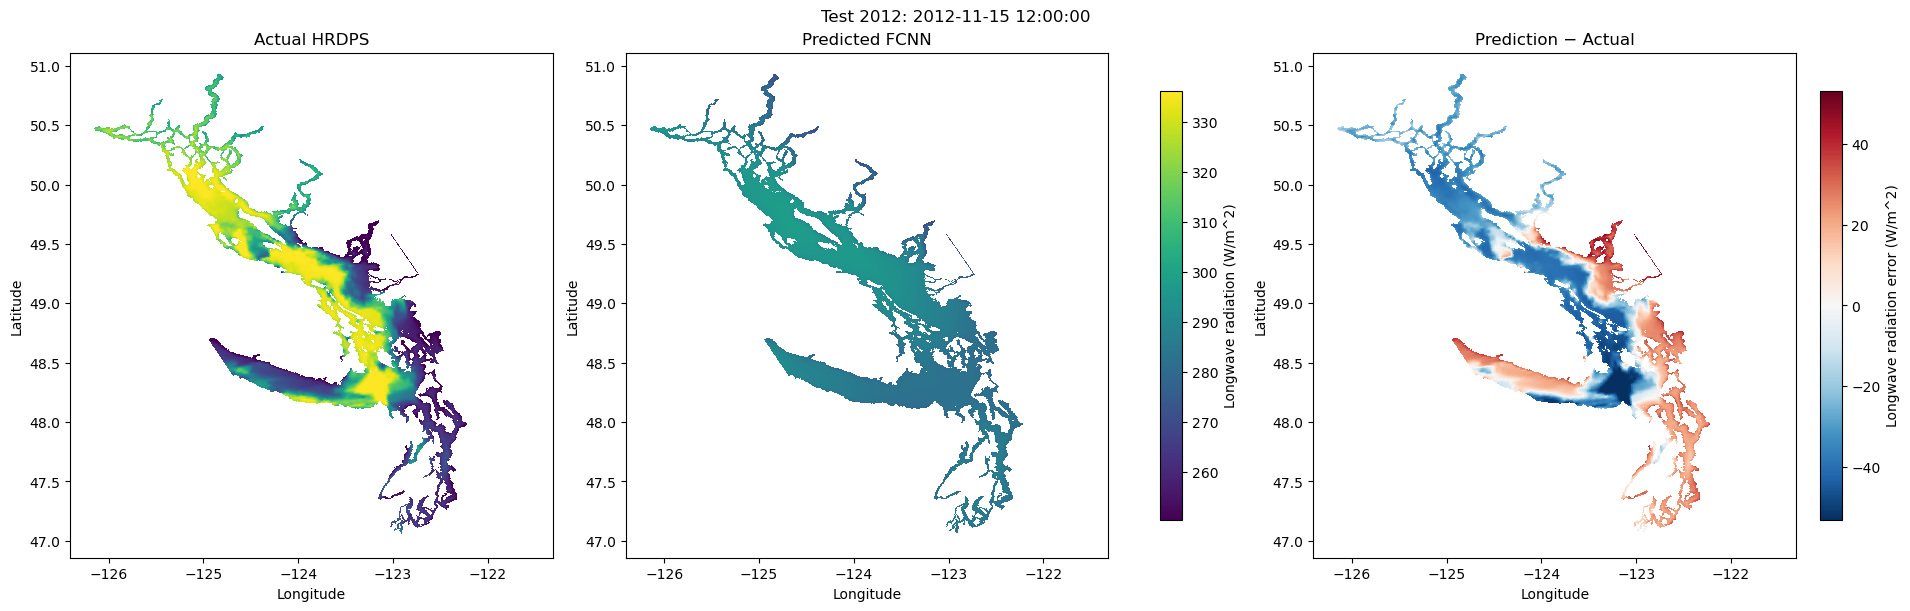

Requested timestamp: 2012-11-15 12:00:00
Selected timestamp: 2012-11-15 12:00:00


In [54]:
validation_spatial_timestamps = ["2008-02-15 12:00:00", "2008-08-15 12:00:00", "2008-11-15 12:00:00"]

for timestamp in validation_spatial_timestamps:
    plot_spatial_pattern(val_times, X_hrdps_val, X_hrdps_val_pred, timestamp, "Validation 2008")

test_spatial_timestamps = ["2012-02-15 12:00:00", "2012-08-15 12:00:00", "2012-11-15 12:00:00"]

for timestamp in test_spatial_timestamps:
    plot_spatial_pattern(test_times, X_hrdps_test, X_hrdps_test_pred, timestamp, "Test 2012")

In [55]:
pca_only_metrics_table

,split,rmse,normalized_rmse,mae,bias,grid_cell_r2,domain_mean_r2,number_valid_values
0,validation,5.091574,0.142566,3.111521,-0.000069,0.979429,1.0,237638360
1,test,5.399648,0.166274,3.264580,-0.000188,0.972023,1.0,236987296
